In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/My Drive/Minor 5th Sem/embedded_gptneo.csv'
gpt_neo_embeddings = pd.read_csv(file_path)
print(gpt_neo_embeddings.head())


   annotator_id  platform  emotionaldistress  provokingviolence  \
0          3379         3                  2                  2   
1           488         0                  2                  2   
2          3275         0                  2                  1   
3          6801         0                  2                  0   
4         10615         0                  2                  2   

   individualharrassment                                          embedding  
0                      3  [0.004455165937542915, 0.33095115423202515, -0...  
1                      3  [0.8477875590324402, 1.9735788106918335, -1.19...  
2                      2  [0.011255793273448944, 1.4634126424789429, -0....  
3                      2  [-0.11528337001800537, 1.7641595602035522, -0....  
4                      3  [0.2188192456960678, 1.6596447229385376, -0.95...  


In [ ]:
import pandas as pd

file_path = '/content/drive/My Drive/Minor 5th Sem/bert_embedded_dataset.csv'
bert_embeddings = pd.read_csv(file_path)
print(bert_embeddings.head())


   annotator_id                                      embedded_text  \
0          3379  [-0.2818194627761841, 0.3122991919517517, -0.0...   
1           488  [-0.4389492869377136, -0.4469502866268158, -0....   
2          3275  [0.07826860249042511, 0.41834571957588196, 0.2...   
3          6801  [0.21192581951618195, 0.4548655152320862, -0.0...   
4         10615  [-0.16936637461185455, 0.056792572140693665, 0...   

   emotionaldistress  provokingviolence  individualharrassment  
0                  2                  2                      3  
1                  2                  2                      3  
2                  2                  1                      2  
3                  2                  0                      2  
4                  2                  2                      3  


In [ ]:
gpt_neo_embeddings['embedding'] = gpt_neo_embeddings['embedding'].apply(lambda x: eval(x))
bert_embeddings['embedded_text'] = bert_embeddings['embedded_text'].apply(lambda x: eval(x))

import torch
gpt_neo_tensor = torch.tensor(gpt_neo_embeddings['embedding'].tolist())
bert_tensor = torch.tensor(bert_embeddings['embedded_text'].tolist())

print(gpt_neo_tensor.shape, bert_tensor.shape)

torch.Size([54932, 768]) torch.Size([54932, 768])


In [ ]:
import torch.nn as nn

dim_gpt_neo = gpt_neo_tensor.size(1)
dim_bert = bert_tensor.size(1)

common_dim = max(dim_gpt_neo, dim_bert)

linear_gpt_neo = nn.Linear(dim_gpt_neo, common_dim)
linear_bert = nn.Linear(dim_bert, common_dim)

projected_gpt_neo = linear_gpt_neo(gpt_neo_tensor)
projected_bert = linear_bert(bert_tensor)

print(projected_gpt_neo.shape, projected_bert.shape)  # Both should have the same shape now


torch.Size([54932, 768]) torch.Size([54932, 768])


In [ ]:
# Concatenate
concatenated_embeddings = torch.cat((projected_gpt_neo, projected_bert), dim=1)
print(concatenated_embeddings.shape)  # Should be [54932, 768 + 768] = [54932, 1536]


torch.Size([54932, 1536])


In [ ]:
new_embedding_layer = nn.Embedding.from_pretrained(concatenated_embeddings)

print(new_embedding_layer)

Embedding(54932, 1536)


In [ ]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
import pandas as pd

# Original labels
y = gpt_neo_embeddings[['emotionaldistress', 'provokingviolence', 'individualharrassment']].values

y_binary = (y > 0).astype(int)

# Add binarized labels as new columns
gpt_neo_embeddings['emotionaldistress_binary'] = y_binary[:, 0]
gpt_neo_embeddings['provokingviolence_binary'] = y_binary[:, 1]
gpt_neo_embeddings['individualharrassment_binary'] = y_binary[:, 2]

output_path = '/content/drive/My Drive/Minor 5th Sem/updated_dataset_with_binary_labels.csv'
gpt_neo_embeddings.to_csv(output_path, index=False)

print(f"Updated dataset saved to {output_path}")


Updated dataset saved to /content/drive/My Drive/Minor 5th Sem/updated_dataset_with_binary_labels.csv


In [ ]:
gpt_neo_embeddings.head(100)

,annotator_id,platform,emotionaldistress,provokingviolence,individualharrassment,embedding,emotionaldistress_binary,provokingviolence_binary,individualharrassment_binary
0,3379,3,2,2,3,"[0.004455165937542915, 0.33095115423202515, -0...",1,1,1
1,488,0,2,2,3,"[0.8477875590324402, 1.9735788106918335, -1.19...",1,1,1
2,3275,0,2,1,2,"[0.011255793273448944, 1.4634126424789429, -0....",1,1,1
3,6801,0,2,0,2,"[-0.11528337001800537, 1.7641595602035522, -0....",1,0,1
4,10615,0,2,2,3,"[0.2188192456960678, 1.6596447229385376, -0.95...",1,1,1
...,...,...,...,...,...,...,...,...,...
95,9640,3,2,1,3,"[0.1726282835006714, 0.9376043677330017, -1.15...",1,1,1
96,10409,0,2,2,2,"[0.4967760443687439, 2.125267267227173, -0.808...",1,1,1
97,9273,2,2,2,2,"[0.7127152681350708, 0.8172300457954407, -0.89...",1,1,1
98,8495,0,2,2,2,"[-0.2925843298435211, 2.1565797328948975, -0.7...",1,1,1


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(concatenated_embeddings.detach().numpy(), y_binary, test_size=0.2, random_state=42)

class MultilabelDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = embeddings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.embeddings[idx], dtype=torch.float32),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32)
        }

train_dataset = MultilabelDataset(X_train, y_train)
val_dataset = MultilabelDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
# Hybrid Model with CNN, BiLSTM, and Separate Attention Layers
class HybridCNNBiLSTMClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(HybridCNNBiLSTMClassifier, self).__init__()

        # CNN layers
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=128, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)

        # BiLSTM layer
        self.bilstm = nn.LSTM(input_size=256, hidden_size=128, num_layers=1, batch_first=True, bidirectional=True)

        # Shared fully connected layer
        self.fc_shared = nn.Linear(128 * 2 * (input_dim // 2), 128)  # Adjusted for BiLSTM output

        # Separate attention and classification layers for each label
        self.attention_emotional = nn.Linear(128, 1)
        self.fc_emotional = nn.Linear(128, 1)

        self.attention_violence = nn.Linear(128, 1)
        self.fc_violence = nn.Linear(128, 1)

        self.attention_harassment = nn.Linear(128, 1)
        self.fc_harassment = nn.Linear(128, 1)

    def forward(self, x):
        # CNN
        x = x.unsqueeze(1)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        # BiLSTM
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.bilstm(x)

        # Flatten for fully connected layer
        x = lstm_out.contiguous().view(lstm_out.size(0), -1)
        shared_features = torch.relu(self.fc_shared(x))  # Shape: [batch_size, 128]


        attn_weights_emotional = torch.softmax(self.attention_emotional(shared_features), dim=1)
        emotional_features = attn_weights_emotional * shared_features
        emotional_output = torch.sigmoid(self.fc_emotional(emotional_features))


        attn_weights_violence = torch.softmax(self.attention_violence(shared_features), dim=1)
        violence_features = attn_weights_violence * shared_features
        violence_output = torch.sigmoid(self.fc_violence(violence_features))


        attn_weights_harassment = torch.softmax(self.attention_harassment(shared_features), dim=1)
        harassment_features = attn_weights_harassment * shared_features
        harassment_output = torch.sigmoid(self.fc_harassment(harassment_features))

        return torch.cat((emotional_output, violence_output, harassment_output), dim=1)

In [ ]:

input_dim = concatenated_embeddings.size(1)  # Number of features(1536)
output_dim = y_binary.shape[1]  # Number of labels

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridCNNBiLSTMClassifier(input_dim=input_dim, output_dim=output_dim).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

def train_model(model, train_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}")

train_model(model, train_loader, criterion, optimizer)

Epoch 1/10, Loss: 0.1653
Epoch 2/10, Loss: 0.1536
Epoch 3/10, Loss: 0.1494
Epoch 4/10, Loss: 0.1461
Epoch 5/10, Loss: 0.1425
Epoch 6/10, Loss: 0.1381
Epoch 7/10, Loss: 0.1326
Epoch 8/10, Loss: 0.1266
Epoch 9/10, Loss: 0.1195
Epoch 10/10, Loss: 0.1131


In [ ]:

def evaluate_model(model, val_loader):
    model.eval()
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].cpu().numpy()

            outputs = model(input_ids).cpu().numpy()
            predictions.append(outputs)
            true_labels.append(labels)

    return np.vstack(predictions), np.vstack(true_labels)

y_pred, y_true = evaluate_model(model, val_loader)

y_pred_binary = (y_pred > 0.5).astype(int)

print(classification_report(y_true, y_pred_binary, target_names=['Emotional Distress', 'Provoking Violence', 'Individual Harassment']))

overall_accuracy = accuracy_score(y_true, y_pred_binary)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

                       precision    recall  f1-score   support

   Emotional Distress       0.99      1.00      1.00     10887
   Provoking Violence       0.85      0.92      0.89      9012
Individual Harassment       0.99      1.00      1.00     10906

            micro avg       0.95      0.98      0.96     30805
            macro avg       0.95      0.97      0.96     30805
         weighted avg       0.95      0.98      0.96     30805
          samples avg       0.95      0.97      0.95     30805

Overall Accuracy: 0.8023


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


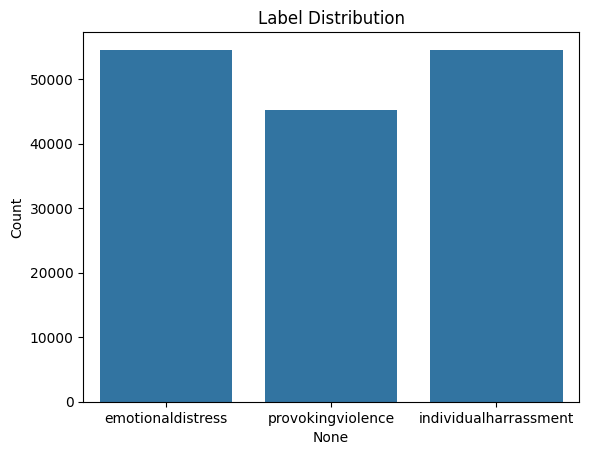

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

label_counts = pd.DataFrame(y_binary, columns=['emotionaldistress', 'provokingviolence', 'individualharrassment']).sum()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Label Distribution')
plt.ylabel('Count')
plt.show()


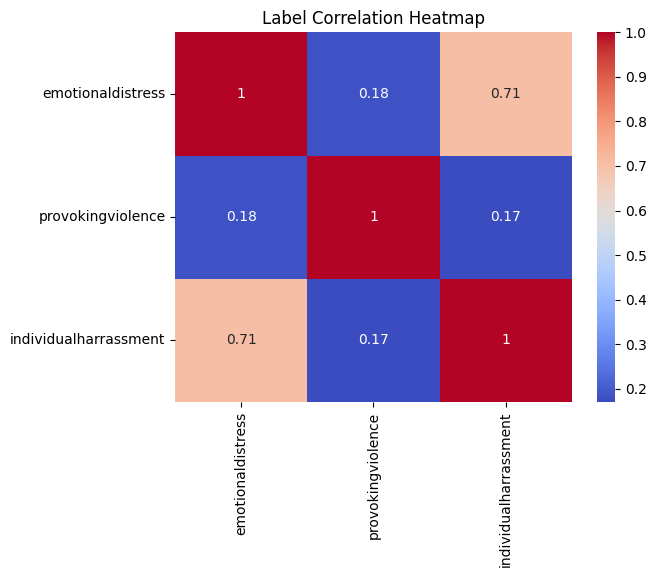

In [ ]:
import seaborn as sns
import pandas as pd

df_labels = pd.DataFrame(y_binary, columns=['emotionaldistress', 'provokingviolence', 'individualharrassment'])

corr_matrix = df_labels.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Label Correlation Heatmap')
plt.show()


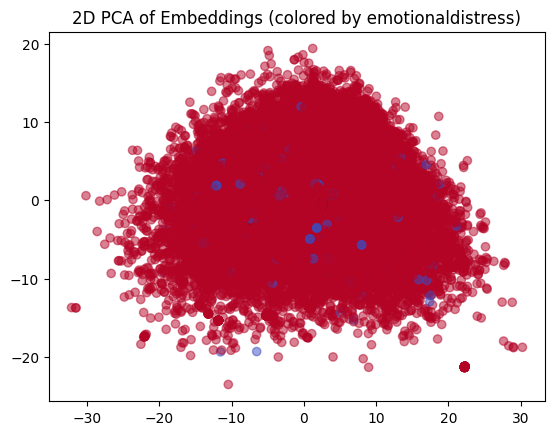

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(concatenated_embeddings.detach().numpy())

# Plot the 2D projection, coloring by one of the labels
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_binary[:, 0], cmap='coolwarm', alpha=0.5)
plt.title('2D PCA of Embeddings (colored by emotionaldistress)')
plt.show()
